# Versión operativa basada en V2.4 Configurable Multimercado

Mantiene la lógica operativa de V2.3 e incorpora un calendario de resultados compacto y tabular.


In [1]:
# ========================= CONFIGURACIÓN =========================
# Activos que aparecerán en el panel.
ACTIVOS = [
    #'META',
    #'SHOP',
    # 'AAPL',
    'NVDA'
    # 'MSFT',
    # 'AMZN',
]

# Deja descomentada EXACTAMENTE UNA línea.
# MODO_OPERATIVO = 'SOLO_LONG'
# MODO_OPERATIVO = 'SOLO_SHORT'
MODO_OPERATIVO = 'LONG_Y_SHORT'

# Fecha hasta la que se analizarán cierres. None/'HOY' utiliza hoy.
FECHA_FIN = None
# FECHA_FIN = '2026-08-26'

# Estado que realmente tienes en IBKR Paper.
# Si estás fuera, usa {'lado': None}.
# Si estás dentro, rellena lado, sistema, fecha y precio REAL de ejecución.
# Sistemas LONG válidos:  'RSI + BOLLINGER'
# Sistemas SHORT válidos: 'RSI > 70' o 'RUPTURA'
POSICIONES_PAPER = {
    'META': {'lado': None},
    'SHOP': {'lado': None},
    # Ejemplo:
    # 'META': {
    #     'lado': 'SHORT', 'sistema': 'RUPTURA',
    #     'fecha': '2026-08-20', 'precio': 535.25
    # },
}

# Parámetros originales de V2.2.
AJUSTAR_DIVIDENDOS = True
STOP_LONG = 0.07
STOP_SHORT = 0.07
PERIODO_RUPTURA = 20
MULTIPLICADOR_VOLUMEN = 1.00
RUPTURA_ATR = 2.0
RUPTURA_MAX_SESIONES = 20
# ================================================================


In [2]:
# ================= IMPORTACIÓN Y DESCARGA =================
import warnings
from pathlib import Path
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from dateutil.relativedelta import relativedelta
from IPython.display import display, HTML

warnings.filterwarnings('ignore')
yf.set_tz_cache_location(str(Path(tempfile.gettempdir()) / 'yf_operativa_v22_cache'))

tickers = [str(t).strip().upper() for t in ACTIVOS]
if not tickers or len(tickers) != len(set(tickers)):
    raise ValueError('ACTIVOS debe contener tickers únicos y al menos uno.')

MODO_OPERATIVO = str(MODO_OPERATIVO).strip().upper()
if MODO_OPERATIVO not in {'SOLO_LONG', 'SOLO_SHORT', 'LONG_Y_SHORT'}:
    raise ValueError("Modo inválido: usa SOLO_LONG, SOLO_SHORT o LONG_Y_SHORT.")

hoy = pd.Timestamp.today().normalize()
fecha_fin_solicitada = (
    hoy if FECHA_FIN is None or str(FECHA_FIN).strip().upper() == 'HOY'
    else pd.Timestamp(FECHA_FIN).normalize()
)
if fecha_fin_solicitada > hoy:
    raise ValueError('FECHA_FIN no puede ser posterior a hoy.')

# Cinco años mantienen el calentamiento de indicadores del V2.2.
inicio_descarga = fecha_fin_solicitada - relativedelta(years=5)
datos_raw, errores = {}, []
for ticker in tickers:
    try:
        d = yf.download(
            ticker, start=inicio_descarga,
            end=fecha_fin_solicitada + pd.Timedelta(days=1),
            interval='1d', auto_adjust=AJUSTAR_DIVIDENDOS, progress=False
        )
        if d.empty:
            raise RuntimeError('descarga vacía')
        if isinstance(d.columns, pd.MultiIndex):
            d.columns = d.columns.get_level_values(0)
        d = d[['Open', 'High', 'Low', 'Close', 'Volume']].dropna().copy()
        d.index = pd.DatetimeIndex(d.index).tz_localize(None).normalize()
        datos_raw[ticker] = d[~d.index.duplicated(keep='last')].sort_index()
    except Exception as exc:
        errores.append(f'{ticker}: {exc}')

if errores:
    raise RuntimeError('Error de descarga:\n' + '\n'.join(errores))

# Última sesión que existe simultáneamente para todos los activos.
sesiones_comunes = set.intersection(*(set(d.index) for d in datos_raw.values()))
if not sesiones_comunes:
    raise RuntimeError('Los activos no tienen sesiones comunes.')
ultima_fecha_comun = max(sesiones_comunes)


In [3]:
# ================= INDICADORES Y SEÑALES V2.2 =================
def preparar_senales(df):
    """Reproduce las señales del Backtester V2.2 sin lookahead."""
    d = df.copy()
    delta = d['Close'].diff()
    subida, bajada = delta.clip(lower=0), -delta.clip(upper=0)
    rs = subida.rolling(14).mean() / bajada.rolling(14).mean()
    d['RSI'] = 100 - 100 / (1 + rs)

    d['BB_MIDDLE'] = d['Close'].rolling(20).mean()
    desviacion = d['Close'].rolling(20).std()
    d['BB_LOWER'] = d['BB_MIDDLE'] - 2 * desviacion
    d['EMA10'] = d['Close'].ewm(span=10, adjust=False).mean()

    cierre_previo = d['Close'].shift(1)
    tr = pd.concat([
        d['High'] - d['Low'],
        (d['High'] - cierre_previo).abs(),
        (d['Low'] - cierre_previo).abs()
    ], axis=1).max(axis=1)
    d['ATR14'] = tr.ewm(alpha=1 / 14, adjust=False).mean()

    d['LONG_ENTRY'] = (d['RSI'] < 30) & (d['Close'] <= d['BB_LOWER'])
    d['LONG_EXIT'] = (d['RSI'] >= 65) | (d['Close'] >= d['BB_MIDDLE'])
    d['MINIMO_20_PREV'] = d['Low'].rolling(PERIODO_RUPTURA).min().shift(1)
    d['VOLUMEN_20_PREV'] = d['Volume'].rolling(PERIODO_RUPTURA).mean().shift(1)
    d['SHORT_RSI'] = d['RSI'] > 70
    d['SHORT_RUPTURA'] = (
        (d['Close'] < d['MINIMO_20_PREV'])
        & (d['Volume'] > d['VOLUMEN_20_PREV'] * MULTIPLICADOR_VOLUMEN)
    )
    return d


datos = {
    ticker: preparar_senales(d.loc[d.index <= ultima_fecha_comun])
    for ticker, d in datos_raw.items()
}


In [4]:
# ================= EVALUACIÓN OPERATIVA =================
def estado_configurado(ticker):
    estado = POSICIONES_PAPER.get(ticker, {'lado': None})
    lado = estado.get('lado')
    if lado is None or str(lado).strip().upper() in {'', 'NINGUNO', 'FUERA', 'NONE'}:
        return {'lado': None}
    return {**estado, 'lado': str(lado).strip().upper()}


def trailing_ruptura(d, fecha_entrada, precio_entrada):
    """Reconstruye causalmente el trailing que V2.2 habría acumulado."""
    tramo = d.loc[d.index >= fecha_entrada]
    trailing = precio_entrada * (1 + STOP_SHORT)
    minimo_desde_entrada = precio_entrada
    for _, fila in tramo.iterrows():
        minimo_desde_entrada = min(minimo_desde_entrada, float(fila['Low']))
        if pd.notna(fila['ATR14']):
            candidato = minimo_desde_entrada + RUPTURA_ATR * float(fila['ATR14'])
            trailing = min(trailing, candidato)
    return trailing, len(tramo)


def evaluar(ticker):
    d = datos[ticker]
    actual = d.iloc[-1]
    fecha_actual = d.index[-1]
    cierre = float(actual['Close'])
    estado = estado_configurado(ticker)

    # Estando fuera, solo una señal del último cierre autoriza una entrada en
    # la próxima apertura. No se persiguen señales históricas atrasadas.
    if estado['lado'] is None:
        if MODO_OPERATIVO != 'SOLO_SHORT' and bool(actual['LONG_ENTRY']):
            return {
                'accion': 'ENTRAR LONG', 'momento': 'PRÓXIMA APERTURA',
                'sistema': 'RSI + BOLLINGER',
                'motivo': f"RSI {actual['RSI']:.1f} y cierre bajo la banda inferior de Bollinger.",
                'stop': cierre * (1 - STOP_LONG),
                'nota_stop': 'Stop orientativo; recalcular al 7% bajo el precio real de ejecución.'
            }
        if MODO_OPERATIVO != 'SOLO_LONG' and bool(actual['SHORT_RUPTURA']):
            return {
                'accion': 'ENTRAR SHORT', 'momento': 'PRÓXIMA APERTURA',
                'sistema': 'RUPTURA',
                'motivo': 'Cierre bajo el mínimo previo de 20 sesiones con volumen superior a su media.',
                'stop': cierre * (1 + STOP_SHORT),
                'nota_stop': 'Stop orientativo; recalcular al 7% sobre el precio real de ejecución.'
            }
        if MODO_OPERATIVO != 'SOLO_LONG' and bool(actual['SHORT_RSI']):
            return {
                'accion': 'ENTRAR SHORT', 'momento': 'PRÓXIMA APERTURA',
                'sistema': 'RSI > 70',
                'motivo': f"RSI en sobrecompra: {actual['RSI']:.1f}.",
                'stop': cierre * (1 + STOP_SHORT),
                'nota_stop': 'Stop orientativo; recalcular al 7% sobre el precio real de ejecución.'
            }
        return {
            'accion': 'PERMANECER FUERA', 'momento': 'AHORA', 'sistema': '—',
            'motivo': f"No hay señal nueva al cierre. RSI: {actual['RSI']:.1f}.",
            'stop': None, 'nota_stop': ''
        }

    # Para gestionar una posición real son imprescindibles estos tres campos.
    faltan = [k for k in ('sistema', 'fecha', 'precio') if estado.get(k) in (None, '')]
    if faltan:
        return {
            'accion': 'REVISAR POSICIÓN', 'momento': 'AHORA', 'sistema': estado.get('sistema', '—'),
            'motivo': 'Faltan en POSICIONES_PAPER: ' + ', '.join(faltan) + '.',
            'stop': None, 'nota_stop': ''
        }

    lado = estado['lado']
    sistema = str(estado['sistema']).strip().upper()
    fecha_entrada = pd.Timestamp(estado['fecha']).normalize()
    precio_entrada = float(estado['precio'])
    if fecha_entrada not in d.index:
        return {
            'accion': 'REVISAR POSICIÓN', 'momento': 'AHORA', 'sistema': sistema,
            'motivo': 'La fecha de entrada no aparece en el histórico descargado.',
            'stop': None, 'nota_stop': ''
        }

    if lado == 'LONG':
        stop = precio_entrada * (1 - STOP_LONG)
        if bool(actual['LONG_EXIT']):
            motivo = f"Salida LONG activada: RSI {actual['RSI']:.1f} o cierre sobre banda media."
            accion, momento = 'SALIR LONG', 'PRÓXIMA APERTURA'
        else:
            motivo = f"LONG vigente: RSI {actual['RSI']:.1f}; no se activó la salida."
            accion, momento = 'MANTENER LONG', 'AHORA'

    elif lado == 'SHORT' and sistema == 'RSI > 70':
        stop = precio_entrada * (1 + STOP_SHORT)
        if bool(actual['RSI'] < 50):
            motivo = f"Salida SHORT RSI activada: RSI {actual['RSI']:.1f} < 50."
            accion, momento = 'SALIR SHORT', 'PRÓXIMA APERTURA'
        else:
            motivo = f"SHORT RSI vigente: RSI {actual['RSI']:.1f} todavía no es inferior a 50."
            accion, momento = 'MANTENER SHORT', 'AHORA'

    elif lado == 'SHORT' and sistema == 'RUPTURA':
        stop, sesiones = trailing_ruptura(d, fecha_entrada, precio_entrada)
        dos_sobre_ema = len(d) >= 2 and bool(
            (d['Close'].iloc[-2:] > d['EMA10'].iloc[-2:]).all()
        )
        if dos_sobre_ema:
            accion, momento = 'SALIR SHORT', 'PRÓXIMA APERTURA'
            motivo = 'Dos cierres consecutivos por encima de EMA10.'
        elif bool(actual['RSI'] > 55):
            accion, momento = 'SALIR SHORT', 'PRÓXIMA APERTURA'
            motivo = f"RSI {actual['RSI']:.1f} > 55: final de la ruptura bajista."
        elif sesiones >= RUPTURA_MAX_SESIONES:
            accion, momento = 'SALIR SHORT', 'PRÓXIMA APERTURA'
            motivo = f"Alcanzado el máximo de {RUPTURA_MAX_SESIONES} sesiones."
        else:
            accion, momento = 'MANTENER SHORT', 'AHORA'
            motivo = f"Ruptura vigente durante {sesiones} sesiones; trailing ATR activo."
    else:
        return {
            'accion': 'REVISAR POSICIÓN', 'momento': 'AHORA', 'sistema': sistema,
            'motivo': f"Combinación no válida de lado ({lado}) y sistema ({sistema}).",
            'stop': None, 'nota_stop': ''
        }

    if (lado == 'LONG' and cierre <= stop) or (lado == 'SHORT' and cierre >= stop):
        accion, momento = 'REVISAR STOP', 'INMEDIATAMENTE'
        motivo = 'El último cierre ha atravesado el stop registrado; comprueba la ejecución en IBKR Paper.'

    return {
        'accion': accion, 'momento': momento, 'sistema': sistema,
        'motivo': motivo, 'stop': stop,
        'nota_stop': 'Orden de protección; un gap puede ejecutarse a un precio peor.'
    }


estados = {ticker: evaluar(ticker) for ticker in tickers}


## Calendario dinámico de eventos — V2.4

Informe vertical organizado en un bloque por cada valor seleccionado en `ACTIVOS`. Dentro de cada bloque aparecen, por filas, todas las presentaciones de resultados y las sesiones con una variación cierre a cierre superior al 7 % durante los últimos seis meses.

También se muestran los eventos importantes publicados para los próximos dos meses, diferenciando fechas exactas y aproximadas. Los titulares y resúmenes se presentan en español; las fechas de resultados continúan compartiéndose con los gráficos de tres y seis meses.


In [5]:
# CALENDARIO DINÁMICO DE EVENTOS — V2.4 (BLOQUES VERTICALES POR VALOR)
# Ejecutar antes de la celda de gráficos. No transmite órdenes ni opera.
from calendario_eventos_v2_4 import generar_calendario_eventos

# Opcional: permite añadir una fecha judicial/corporativa que no exponga una API pública.
# Formato: {"META": [{"fecha": "2026-09-08", "tipo": "Juicio",
#          "resumen": "Descripción", "certeza": "Exacta", "fuente": "https://..."}]}
EVENTOS_CALENDARIO_MANUALES = globals().get("EVENTOS_CALENDARIO_MANUALES", {})

_calendario_v24 = generar_calendario_eventos(
    ACTIVOS, eventos_manuales=EVENTOS_CALENDARIO_MANUALES, mostrar=True
)
FECHAS_RESULTADOS_GRAFICOS = _calendario_v24["FECHAS_RESULTADOS_GRAFICOS"]
DATOS_ALERTA_RESULTADOS = _calendario_v24["DATOS_ALERTA_RESULTADOS"]
FILAS_CALENDARIO_EVENTOS = _calendario_v24["FILAS_CALENDARIO_EVENTOS"]
ARCHIVO_HTML = _calendario_v24["ARCHIVO_HTML"]


Informe V2.4 guardado en: C:\Users\carlos.jimenez\Scripts_Bolsa_GitHub\salida_operativa\calendario_resultados\informe_resultados.html


PANEL OPERATIVO V2.4 — LONG_Y_SHORT — cierre 2026-08-28


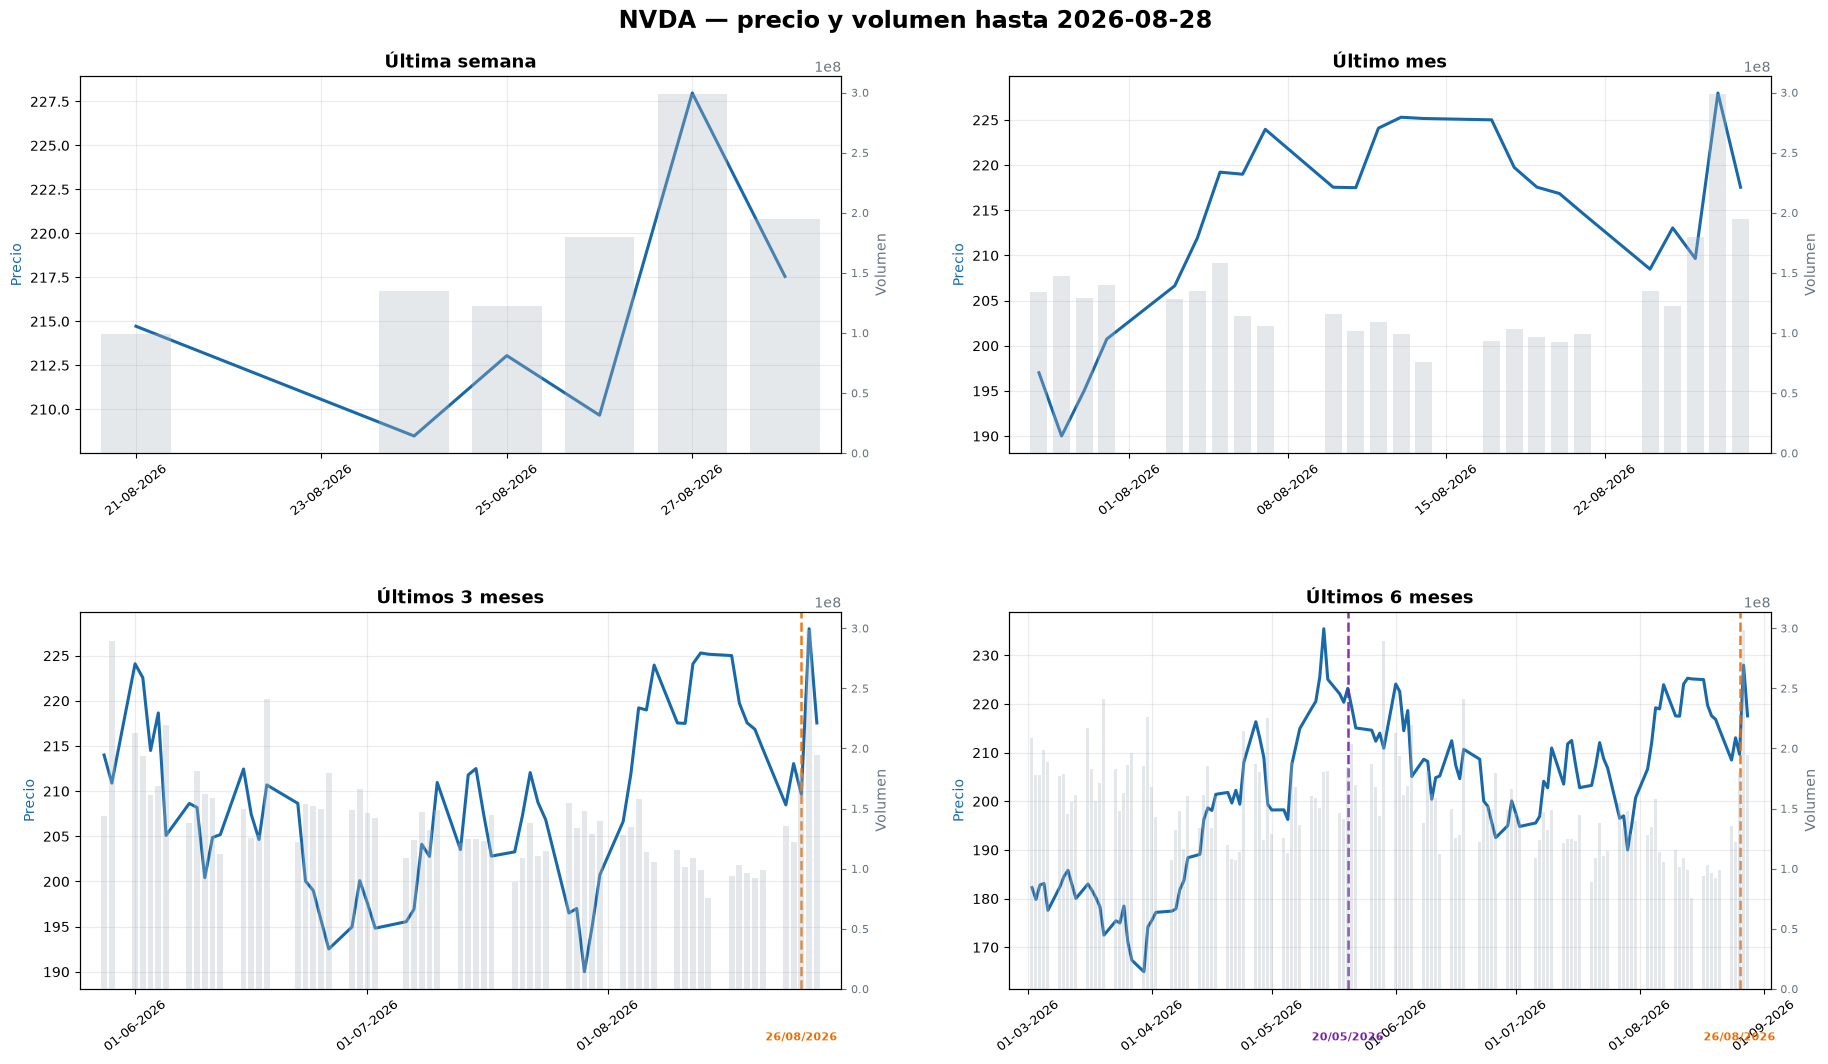

Resumen preparado para correo en: C:\Users\carlos.jimenez\Scripts_Bolsa_GitHub\salida_operativa


In [6]:
# ===================== GRÁFICOS Y PANEL OPERATIVO V2.4 =====================
def dibujar_periodo(ax_precio, d, inicio, titulo, fechas_resultados=None):
    tramo = d.loc[d.index >= inicio]
    ax_volumen = ax_precio.twinx()
    ax_volumen.bar(
        tramo.index, tramo['Volume'], color='#aeb8c2', alpha=.32,
        width=.75, label='Volumen', zorder=1
    )
    ax_precio.plot(
        tramo.index, tramo['Close'], color='#1769aa', lw=2.2,
        label='Precio de cierre', zorder=3
    )
    colores_resultados = ['#ef6c00', '#7b1fa2']
    for indice, fecha_resultado in enumerate(fechas_resultados or []):
        marca = pd.Timestamp(fecha_resultado)
        if marca < tramo.index.min() or marca > tramo.index.max():
            continue
        color = colores_resultados[indice % len(colores_resultados)]
        ax_precio.axvline(marca, color=color, lw=1.8, ls='--', alpha=.9, zorder=4)
        ax_precio.annotate(
            marca.strftime('%d/%m/%Y'), xy=(marca, 0), xycoords=('data', 'axes fraction'),
            xytext=(0, -31), textcoords='offset points', ha='center', va='top',
            fontsize=8, fontweight='bold', color=color, annotation_clip=False
        )
    ax_precio.set_title(titulo, fontsize=13, fontweight='bold')
    ax_precio.set_ylabel('Precio', color='#1769aa')
    ax_volumen.set_ylabel('Volumen', color='#66717c')
    ax_volumen.tick_params(axis='y', labelsize=8, colors='#66717c')
    ax_volumen.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax_precio.grid(alpha=.25)
    ax_precio.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=3, maxticks=7))
    ax_precio.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
    ax_precio.tick_params(axis='x', rotation=38, labelsize=9)
    ax_precio.margins(x=.03)


def construir_alerta_resultados(ticker, fecha_referencia):
    """Construye el aviso usando la fecha analizada, no la hora de ejecución."""
    datos = DATOS_ALERTA_RESULTADOS.get(ticker, {})
    referencia = pd.Timestamp(fecha_referencia).date()
    publicadas = sorted(
        (pd.Timestamp(f).date() for f in datos.get("publicadas", []) if f),
        reverse=True,
    )
    ultima = publicadas[0] if publicadas else None
    proxima = pd.Timestamp(datos["proxima"]).date() if datos.get("proxima") else None

    dias_desde_ultima = (referencia - ultima).days if ultima else None
    # Durante los seis días posteriores prima la advertencia de cuarentena.
    if dias_desde_ultima is not None and 0 <= dias_desde_ultima <= 6:
        distancia = dias_desde_ultima
        mensaje = "Se produjeron HOY" if distancia == 0 else (
            f"Se produjeron hace {distancia} día" + ("" if distancia == 1 else "s")
        )
    elif proxima is not None:
        dias_hasta = (proxima - referencia).days
        if dias_hasta >= 0:
            distancia = dias_hasta
            mensaje = "Se producen HOY" if distancia == 0 else (
                f"Dentro de {distancia} día" + ("" if distancia == 1 else "s")
            )
        else:
            distancia = abs(dias_hasta)
            mensaje = f"Se produjeron hace {distancia} días"
    elif ultima is not None:
        distancia = abs(dias_desde_ultima)
        mensaje = f"Se produjeron hace {distancia} días"
    else:
        return {"mensaje": "Sin alertas de resultados", "color": "#5f6368"}

    if distancia <= 3:
        color = "#c62828"
    elif distancia in (5, 6):
        color = "#1565c0"
    else:
        color = "#5f6368"
    return {"mensaje": mensaje, "color": color}


def tarjeta(ticker, estado, fecha, cierre):
    accion = estado['accion']
    alerta_resultados = construir_alerta_resultados(ticker, fecha)
    if accion.startswith('ENTRAR'):
        fondo, borde = '#d9f7df', '#16823b'
    elif accion.startswith('SALIR') or accion.startswith('REVISAR STOP'):
        fondo, borde = '#ffe1df', '#c62828'
    elif accion.startswith('MANTENER'):
        fondo, borde = '#dcecff', '#2463a7'
    else:
        fondo, borde = '#eeeeee', '#666666'
    stop = '—' if estado['stop'] is None else f"{estado['stop']:,.2f}"
    return f"""
    <div style='background:{fondo};border-left:8px solid {borde};padding:14px 18px;
                margin:10px 0 28px 0;border-radius:7px;font-family:Arial'>
      <div style='font-size:21px'><b>{ticker}: {accion}</b></div>
      <div style='font-size:14px;font-weight:700;color:{alerta_resultados["color"]};
                  margin:4px 0 8px 0'>
        Alerta resultados: {alerta_resultados["mensaje"]}.
      </div>
      <div><b>Momento:</b> {estado['momento']} &nbsp;|&nbsp;
           <b>Sistema:</b> {estado['sistema']} &nbsp;|&nbsp;
           <b>Stop:</b> {stop}</div>
      <div><b>Cierre analizado:</b> {fecha:%Y-%m-%d} a {cierre:,.2f}</div>
      <div><b>Motivo:</b> {estado['motivo']}</div>
      <div style='font-size:12px;color:#555'>{estado['nota_stop']}</div>
    </div>"""


carpeta_salida = Path('salida_operativa')
carpeta_salida.mkdir(exist_ok=True)
tarjetas_html = []

print(f'PANEL OPERATIVO V2.4 — {MODO_OPERATIVO} — cierre {ultima_fecha_comun.date()}')
for ticker in tickers:
    d = datos[ticker]
    fin = d.index[-1]
    fechas_resultados = FECHAS_RESULTADOS_GRAFICOS.get(ticker, [])
    fig, axes = plt.subplots(2, 2, figsize=(19, 11))
    axes = axes.ravel()
    dibujar_periodo(axes[0], d, fin - pd.Timedelta(days=7), 'Última semana')
    dibujar_periodo(axes[1], d, fin - relativedelta(months=1), 'Último mes')
    dibujar_periodo(
        axes[2], d, fin - relativedelta(months=3), 'Últimos 3 meses', fechas_resultados
    )
    dibujar_periodo(
        axes[3], d, fin - relativedelta(months=6), 'Últimos 6 meses', fechas_resultados
    )
    fig.suptitle(f'{ticker} — precio y volumen hasta {fin:%Y-%m-%d}', fontsize=17, fontweight='bold')
    fig.subplots_adjust(left=.06, right=.95, top=.92, bottom=.09, hspace=.42, wspace=.22)
    fig.savefig(carpeta_salida / f'{ticker}_panel.png', dpi=145, bbox_inches='tight')
    plt.show()
    html_ticker = tarjeta(ticker, estados[ticker], fin, float(d['Close'].iloc[-1]))
    tarjetas_html.append(html_ticker)
    display(HTML(html_ticker))

resumen_html = f"""<!doctype html><html><body style='font-family:Arial'>
<h2>Panel operativo V2.4 — {MODO_OPERATIVO}</h2>
<p>Cierre analizado: <b>{ultima_fecha_comun.date()}</b></p>
{''.join(tarjetas_html)}
<p style='font-size:12px;color:#666'>Las indicaciones ENTRAR/SALIR se ejecutan en la próxima apertura.
Comprueba siempre las posiciones y órdenes de protección en IBKR Paper.</p>
</body></html>"""
(carpeta_salida / 'resumen_operativo.html').write_text(resumen_html, encoding='utf-8')
print('Resumen preparado para correo en:', carpeta_salida.resolve())


## Uso diario

1. Actualiza `POSICIONES_PAPER` con lo que realmente tienes ejecutado en IBKR Paper.
2. Ejecuta todas las celdas después del cierre estadounidense.
3. Una indicación `ENTRAR` o `SALIR` se refiere a la próxima apertura.
4. Introduce en `POSICIONES_PAPER` el precio y fecha reales después de una ejecución.
5. Mantén siempre la orden de protección en IBKR; este notebook no transmite ni confirma órdenes.

La disponibilidad y el coste de préstamo de una acción en corto no están incluidos en el cálculo.
